# Car Price Prediction with Machine Learning

This notebook predicts used-car selling prices from age, mileage, fuel type, transmission, brand, and vehicle specifications.

**Dataset:** [Vehicle dataset from CarDekho (Kaggle)](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho), using \`Car details v3.csv\` (8,128 listings). The downloaded source is stored in \`data/cardekho_source/\`. Prices are in INR.


In [1]:
import pandas as pd
import numpy as np
import re
import re
import re
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.impute import SimpleImputer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = 'data/cardekho_source/Car details v3.csv'
df = pd.read_csv(DATA_PATH)
print('Raw dataset shape:', df.shape)
df.head()

Raw dataset shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [3]:
# Data cleaning: inspect, remove duplicates, standardize categories, and parse units
print("Duplicates before removal:", df.duplicated().sum())
display(df.isna().sum().to_frame("missing before cleaning"))
df = df.drop_duplicates().copy()

categorical_columns = ['fuel', 'seller_type', 'transmission', 'owner']
for column in categorical_columns:
    df[column] = df[column].astype('string').str.strip().str.title()
df['fuel'] = df['fuel'].replace({'Cng': 'CNG', 'Lpg': 'LPG'})

def first_number(value):
    match = re.search(r'\d+(?:\.\d+)?', str(value))
    return float(match.group()) if match else np.nan

for column in ['mileage', 'engine', 'max_power']:
    df[column] = df[column].map(first_number)
for column in ['year', 'selling_price', 'km_driven', 'seats']:
    df[column] = pd.to_numeric(df[column], errors='coerce')

required = ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'transmission']
df = df.dropna(subset=required)
df = df[df['selling_price'] > 0].reset_index(drop=True)
print('Cleaned shape:', df.shape)
display(df.isna().sum().to_frame("missing after cleaning"))
df.head()


Duplicates before removal: 1202


,missing before cleaning
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


Cleaned shape: (6926, 13)


,missing after cleaning
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,208
engine,208


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
# Feature engineering: calculate car age and extract brand from name
CURRENT_YEAR = 2026
df['car_age'] = CURRENT_YEAR - df['year']
df = df[df['car_age'].between(0, 50)].copy()
df['brand'] = df['name'].str.split().str[0].str.strip().str.title()

print('Reference year:', CURRENT_YEAR)
display(df[['name', 'year', 'car_age', 'brand']].head())
display(df['brand'].value_counts().head(15).to_frame('listings'))


Reference year: 2026


,name,year,car_age,brand
0,Maruti Swift Dzire VDI,2014,12,Maruti
1,Skoda Rapid 1.5 TDI Ambition,2014,12,Skoda
2,Honda City 2017-2020 EXi,2006,20,Honda
3,Hyundai i20 Sportz Diesel,2010,16,Hyundai
4,Maruti Swift VXI BSIII,2007,19,Maruti


,listings
brand,
Maruti,2165
Hyundai,1267
Mahindra,723
Tata,647
Honda,362
Ford,361
Toyota,357
Chevrolet,216
Renault,206


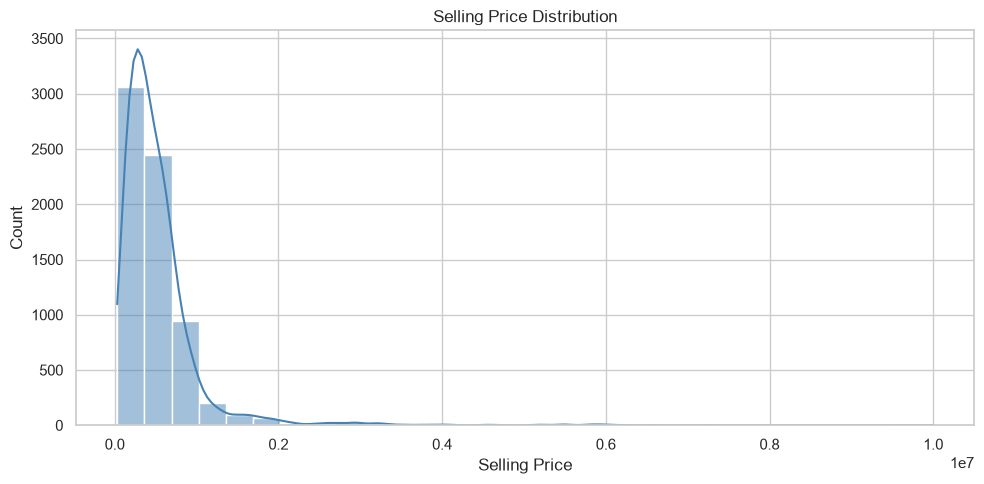

C:\Users\asus\AppData\Local\Temp\ipykernel_18228\2398855540.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fuel', y='selling_price', palette='Set2')


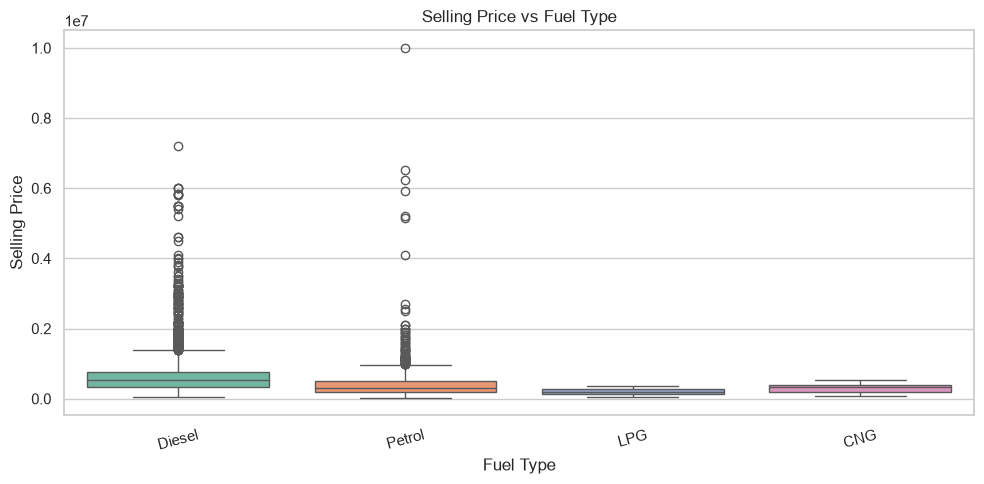

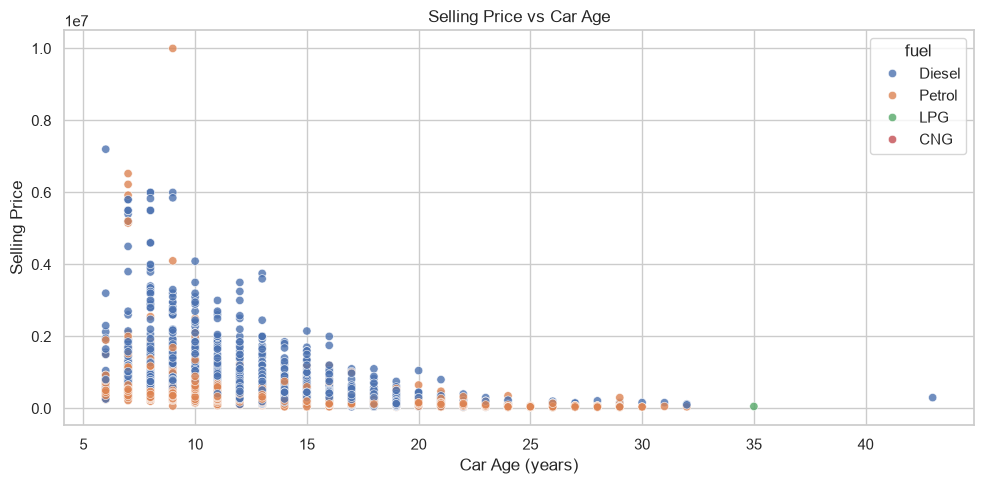

In [5]:
# EDA: Distribution of selling prices
plt.figure(figsize=(10, 5))
sns.histplot(df['selling_price'], bins=30, kde=True, color='steelblue')
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Price vs. fuel type box plot
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='fuel', y='selling_price', palette='Set2')
plt.title('Selling Price vs Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Price vs. car age scatter plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='car_age', y='selling_price', hue='fuel', alpha=0.8)
plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()

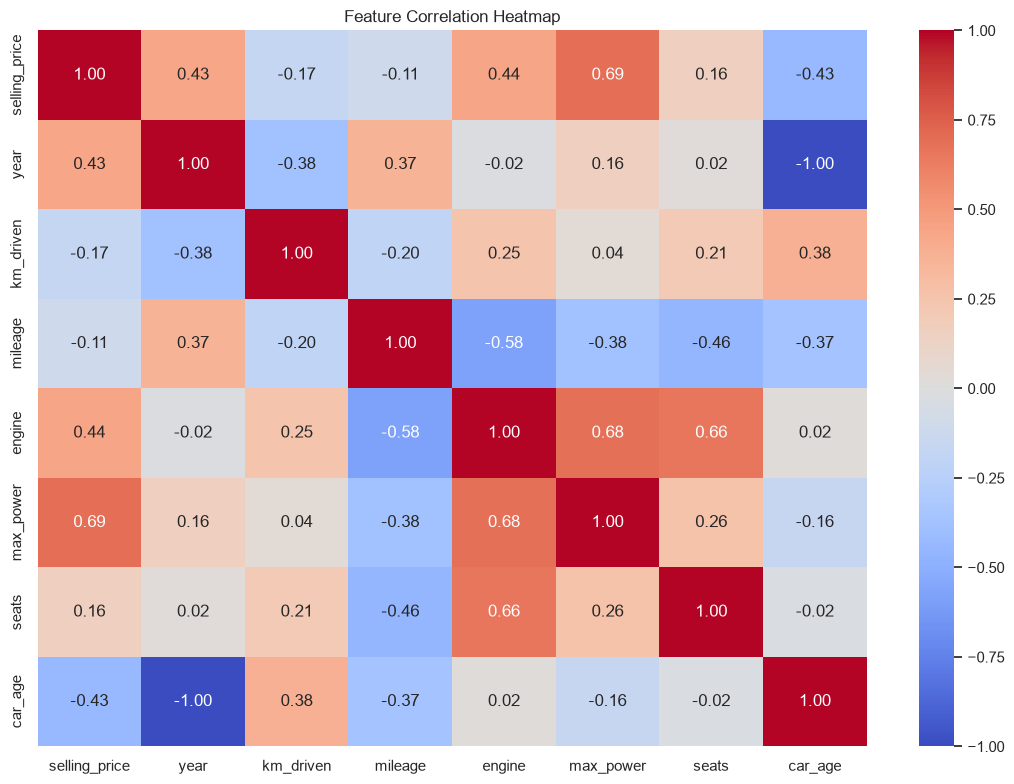

In [6]:
# Correlation heatmap
numeric_features = ['selling_price', 'year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'car_age']
corr = df[numeric_features].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [7]:
# Select features, split data, and prepare one-hot encoding
target = 'selling_price'
feature_columns = ['km_driven', 'fuel', 'seller_type', 'transmission', 'owner',
                   'mileage', 'engine', 'max_power', 'seats', 'brand', 'car_age']
X, y = df[feature_columns], df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Training rows:', len(X_train), '| Test rows:', len(X_test))

numeric_features = ['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'car_age']
categorical_features = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
preprocess = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scale', StandardScaler())]), numeric_features),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
])


Training rows: 5540 | Test rows: 1386


In [8]:
# Train at least 2 regression models: Linear Regression, Random Forest, Gradient Boosting
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
    print(f'{name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}')

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df

Linear Regression - MAE: 133099.12, RMSE: 261925.71, R²: 0.6872


Random Forest - MAE: 73392.69, RMSE: 128712.75, R²: 0.9245


Gradient Boosting - MAE: 82711.28, RMSE: 130971.92, R²: 0.9218


,Model,MAE,RMSE,R2
0,Random Forest,73392.694841,128712.750651,0.924463
1,Gradient Boosting,82711.284307,130971.919906,0.921788
2,Linear Regression,133099.124215,261925.712776,0.687194


In [9]:
# Select the best model using the highest held-out test R2 score
best_model_name = results_df.iloc[0]['Model']
print('Best model:', best_model_name)


Best model: Random Forest


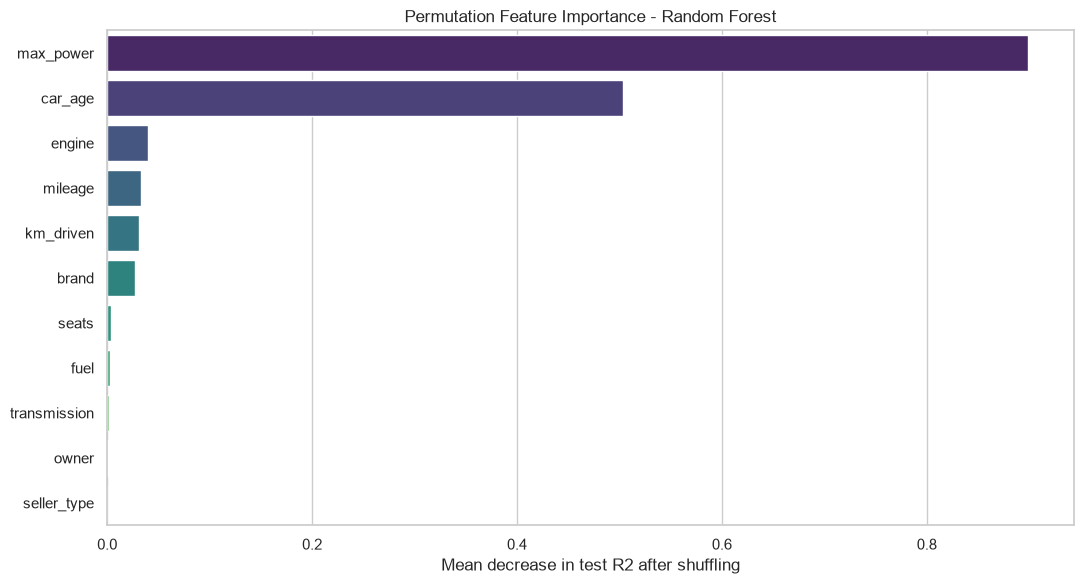

,Feature,Importance
7,max_power,0.898716
10,car_age,0.503883
6,engine,0.039627
5,mileage,0.033106
0,km_driven,0.031469
9,brand,0.027530
8,seats,0.003568
1,fuel,0.002374
3,transmission,0.001970
4,owner,0.000701


In [10]:
# Feature importance chart for the best-performing model
# Permutation importance works for any selected model and keeps original feature labels.
from sklearn.inspection import permutation_importance

best_pipe = Pipeline([('preprocess', preprocess), ('model', models[best_model_name])])
best_pipe.fit(X_train, y_train)
permutation = permutation_importance(
    best_pipe, X_test, y_test, n_repeats=8, random_state=42, scoring='r2', n_jobs=-1
)
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': permutation.importances_mean
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', hue='Feature',
            legend=False, palette='viridis')
plt.title(f'Permutation Feature Importance - {best_model_name}')
plt.xlabel('Mean decrease in test R2 after shuffling')
plt.ylabel('')
plt.tight_layout()
plt.show()
importance_df
